<a href="https://colab.research.google.com/github/tania-maria/telecom-churn-analysis_/blob/main/Challenge2_data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 1. Obtenha a URL do JSON no GitHub

O arquivo está neste repositório:
📁 TelecomX_Data.json — parte do projeto challenge2-data-science no GitHub

A URL bruta é esta:

https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json



2. Importação e carregamento dos dados:

In [36]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# URL bruta do JSON no GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

# Faz a requisição GET na API/arquivo online
response = requests.get(url)

# Converte para Python (dicionário/lista)
dados_json = response.json()

# Transforma em DataFrame tabular
df = pd.json_normalize(dados_json)

# Mostra as primeiras linhas
print(df.head())

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

3. Instale as bibliotecas se necessário

In [37]:
pip install requests pandas

1️⃣ Exploração inicial dos dados


In [38]:
print(df.shape)        # linhas e colunas

(7267, 21)


In [103]:
print(df.isnull().sum())

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [39]:
print(df.columns)      # nomes das colunas

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


In [40]:
print(df.info())       # tipos de dados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [41]:
print(df.head())       # primeiras linhas

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

🧹 2️⃣ Limpeza de dados (Data Cleaning)

Remover espaços

In [42]:
df['Churn'] = df['Churn'].str.strip()

Verificando valores únicos

In [43]:
print(df['Churn'].unique())

['No' 'Yes' '']


Verificando se ainda existir valor estranho para remover:

In [44]:
df = df[df['Churn'].isin(['Yes', 'No'])]
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


1️⃣ Verificar duplicados

In [45]:
df.duplicated().sum()
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


🧹 4️⃣ Corrigir o problema

In [46]:
df = df.drop_duplicates()
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


3️⃣ Analisar evasão (Churn)

In [47]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [48]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


Verificar novamente:

4️⃣ Análise inicial do Churn

In [49]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [50]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [51]:
df['account.Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [52]:
df['account.PaymentMethod'].unique()


array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [53]:
df['internet.InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

3️⃣ Verificado tipos incorretos

In [54]:
df['account.Charges.Total']

,account.Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4
...,...
7262,742.9
7263,1873.7
7264,92.75
7265,4627.65


In [55]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [56]:
df['account.Charges.Total'].isnull().sum()

np.int64(11)

Removendo apenas as linhas onde essa coluna está nula.

In [57]:
df['account.Charges.Total'].isnull().sum()

np.int64(11)

In [58]:
df['account.Charges.Total'].isnull().sum()

np.int64(11)

In [59]:
df = df.dropna(subset=['account.Charges.Total'])

In [60]:
df.shape

(7032, 21)

Criando uma nova coluna:

In [61]:
df['account.Charges.Monthly']

,account.Charges.Monthly
0,65.60
1,59.90
2,73.90
3,98.00
4,83.90
...,...
7262,55.15
7263,85.10
7264,50.30
7265,67.85


🚀 Criando coluna corretamente:

In [62]:
df.loc[:, 'Contas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

/tmp/ipykernel_1698/1051409382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Contas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)


In [63]:
df = df.copy()

In [64]:
df['Contas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


Verificando:

In [65]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


1️⃣ Converter "Yes/No" para 1 e 0

In [66]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Para colunas binárias:

In [67]:
colunas_binarias = [
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'account.PaperlessBilling'
]

for col in colunas_binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

Renomear colunas

In [68]:
df.columns = df.columns.str.replace('.', '_', regex=False)
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

Traduzir colunas

In [69]:
df.rename(columns={
    'customer.gender': 'Genero',
    'account.Contract': 'Tipo_Contrato',
    'account.PaymentMethod': 'Forma_Pagamento'
}, inplace=True)

📊 Análise Descritiva

Estatísticas das colunas numéricas

In [70]:
df.describe()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Contas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


Análise de cancelamento:

In [71]:
df[['customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total',
    'Contas_Diarias']].describe()

,customer_tenure,account_Charges_Monthly,account_Charges_Total,Contas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159891
std,24.545260,30.085974,2266.771362,1.002955
min,1.000000,18.250000,18.800000,0.610000
25%,9.000000,35.587500,401.450000,1.187500
50%,29.000000,70.350000,1397.475000,2.340000
75%,55.000000,89.862500,3794.737500,2.992500
max,72.000000,118.750000,8684.800000,3.960000


Taxa geral de churn

In [72]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


In [73]:
df.groupby('Churn')['customer_tenure'].mean()

,customer_tenure
Churn,
0,37.650010
1,17.979133


O churn é maior em qual tipo de contrato?

In [74]:
df.groupby('account_Contract')['Churn'].mean() * 100

,Churn
account_Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


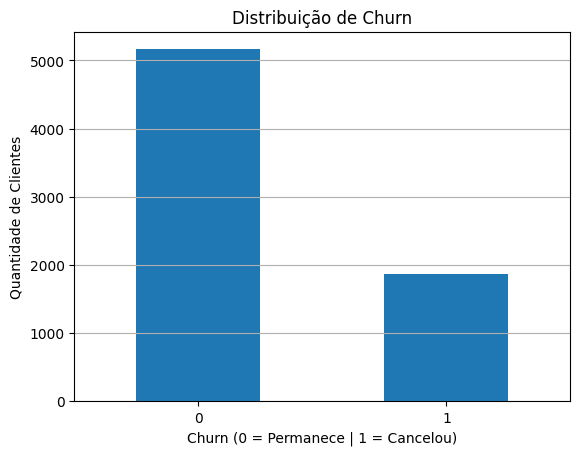

In [75]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title('Distribuição de Churn')
plt.xlabel('Churn (0 = Permanece | 1 = Cancelou)')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)      # Deixa os rótulos retos
plt.grid(axis='y')          # Coloca grade horizontal
plt.show()

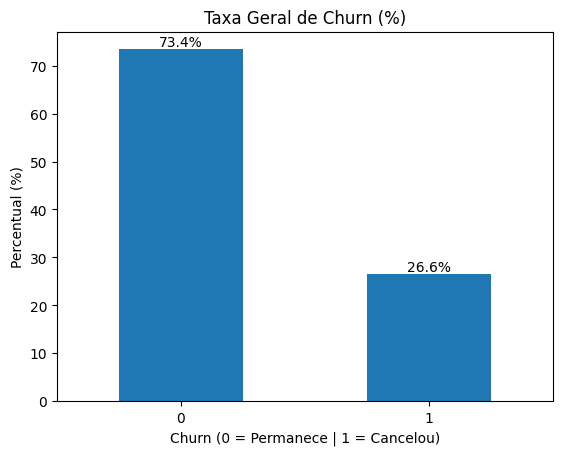

In [76]:
ax = (df['Churn'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Taxa Geral de Churn (%)')
plt.xlabel('Churn (0 = Permanece | 1 = Cancelou)')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

Tempo Médio por Churn

Esse gráfico deixa muito claro que quem cancela fica muito menos tempo.

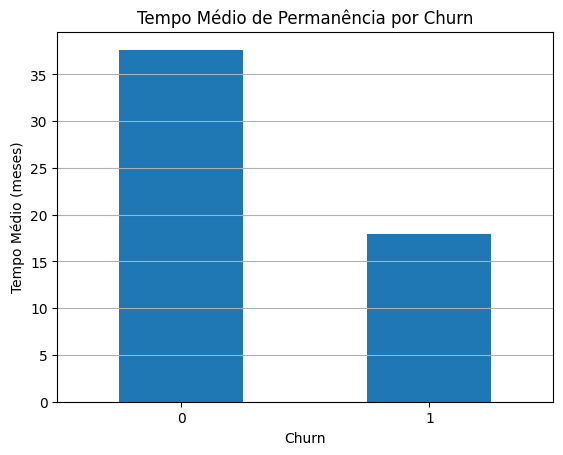

In [77]:
df.groupby('Churn')['customer_tenure'].mean().plot(kind='bar')
plt.title('Tempo Médio de Permanência por Churn')
plt.ylabel('Tempo Médio (meses)')
plt.xticks(rotation=0)      # Deixa os rótulos retos
plt.grid(axis='y')          # Coloca grade horizontal
plt.show()

Churn por Tipo de Contrato

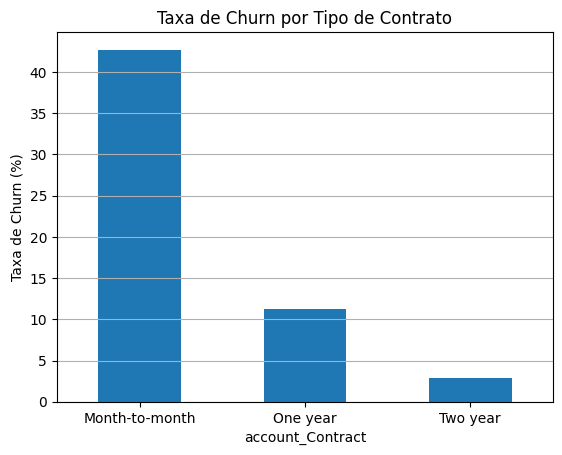

In [78]:
(df.groupby('account_Contract')['Churn'].mean() * 100).plot(kind='bar')
plt.title('Taxa de Churn por Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')
plt.xticks(rotation=0)      # Deixa os rótulos retos
plt.grid(axis='y')          # Coloca grade horizontal
plt.show()

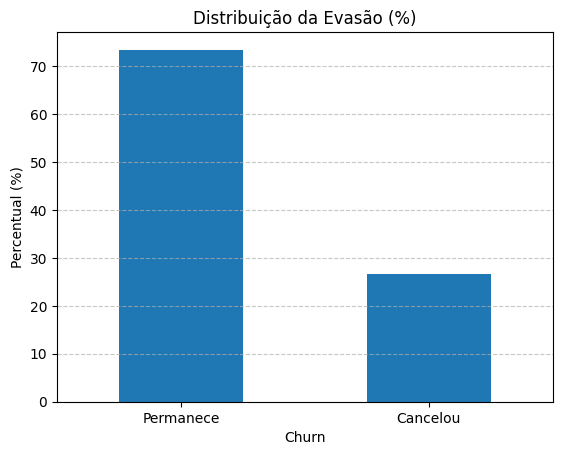

In [79]:
ax = (df['Churn']
      .map({0: 'Permanece', 1: 'Cancelou'})
      .value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Distribuição da Evasão (%)')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [80]:
df.groupby('account_Contract')

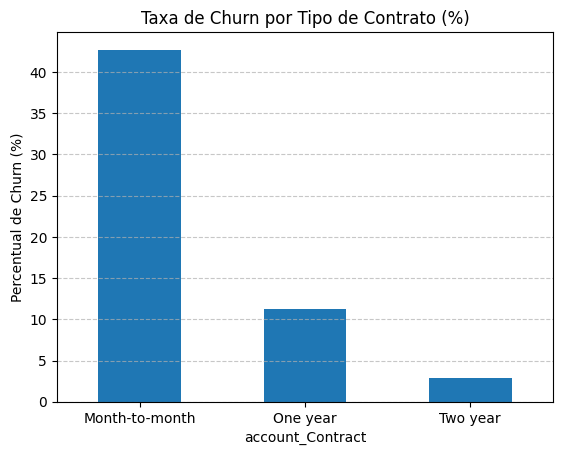

In [81]:
import matplotlib.pyplot as plt

(df.groupby('account_Contract')['Churn'].mean() * 100).plot(kind='bar')

plt.title('Taxa de Churn por Tipo de Contrato (%)')
plt.ylabel('Percentual de Churn (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

👩‍🦰 Churn por Gênero

In [82]:
df.groupby('customer_gender')['Churn'].mean() * 100

,Churn
customer_gender,
Female,26.959518
Male,26.204565


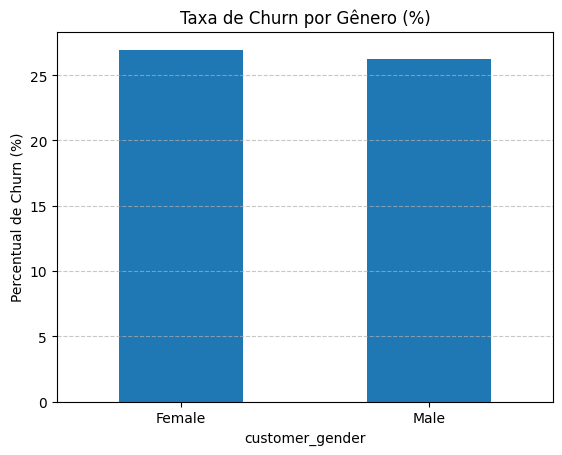

In [83]:
(df.groupby('customer_gender')['Churn'].mean() * 100).plot(kind='bar')

plt.title('Taxa de Churn por Gênero (%)')
plt.ylabel('Percentual de Churn (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

💳 Churn por Método de Pagamento

In [84]:
df.groupby('account_PaymentMethod')['Churn'].mean() * 100

,Churn
account_PaymentMethod,
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123
Electronic check,45.285412
Mailed check,19.201995


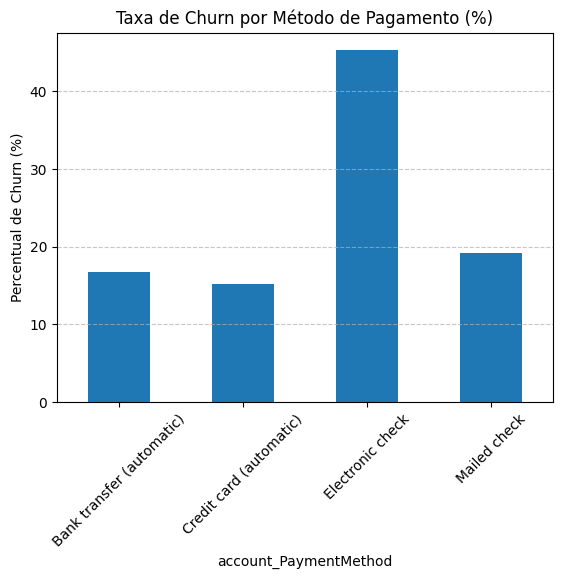

In [85]:
(df.groupby('account_PaymentMethod')['Churn'].mean() * 100).plot(kind='bar')

plt.title('Taxa de Churn por Método de Pagamento (%)')
plt.ylabel('Percentual de Churn (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

🌐 Churn por Tipo de Internet

In [86]:
df.groupby('internet_InternetService')['Churn'].mean() * 100

,Churn
internet_InternetService,
DSL,18.998344
Fiber optic,41.892765
No,7.434211


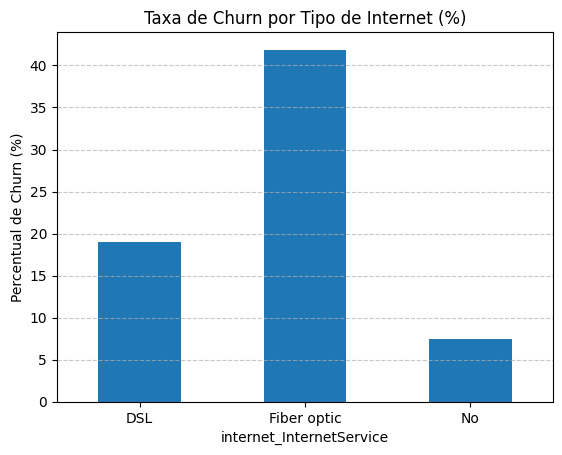

In [87]:
(df.groupby('internet_InternetService')['Churn'].mean() * 100).plot(kind='bar')

plt.title('Taxa de Churn por Tipo de Internet (%)')
plt.ylabel('Percentual de Churn (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

descobrir os nomes reais das colunas

In [88]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

In [89]:
for col in df.columns:
    print(col)

customerID
Churn
customer_gender
customer_SeniorCitizen
customer_Partner
customer_Dependents
customer_tenure
phone_PhoneService
phone_MultipleLines
internet_InternetService
internet_OnlineSecurity
internet_OnlineBackup
internet_DeviceProtection
internet_TechSupport
internet_StreamingTV
internet_StreamingMovies
account_Contract
account_PaperlessBilling
account_PaymentMethod
account_Charges_Monthly
account_Charges_Total
Contas_Diarias


Descobrir só as numéricas

In [90]:
df.select_dtypes(include=['int64','float64']).columns

Index(['Churn', 'customer_SeniorCitizen', 'customer_Partner',
       'customer_Dependents', 'customer_tenure', 'phone_PhoneService',
       'account_PaperlessBilling', 'account_Charges_Monthly',
       'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

Descobrindo o nome correto:

In [91]:
df.groupby('Churn')[['customer_tenure',
                     'account_Charges_Monthly',
                     'account_Charges_Total']].mean()

,customer_tenure,account_Charges_Monthly,account_Charges_Total
Churn,,,
0,37.650010,61.307408,2555.344141
1,17.979133,74.441332,1531.796094


Gráfico Cobrança Mensal

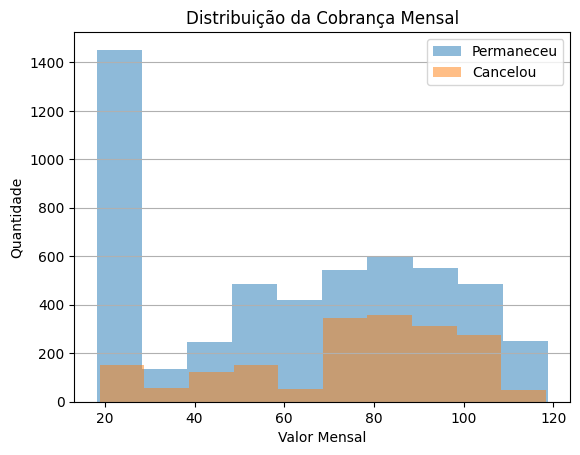

In [92]:
plt.hist(df[df['Churn'] == 0]['account_Charges_Monthly'], alpha=0.5, label='Permaneceu')
plt.hist(df[df['Churn'] == 1]['account_Charges_Monthly'], alpha=0.5, label='Cancelou')

plt.title('Distribuição da Cobrança Mensal')
plt.xlabel('Valor Mensal')
plt.ylabel('Quantidade')
plt.legend()
plt.grid(axis='y')
plt.show()

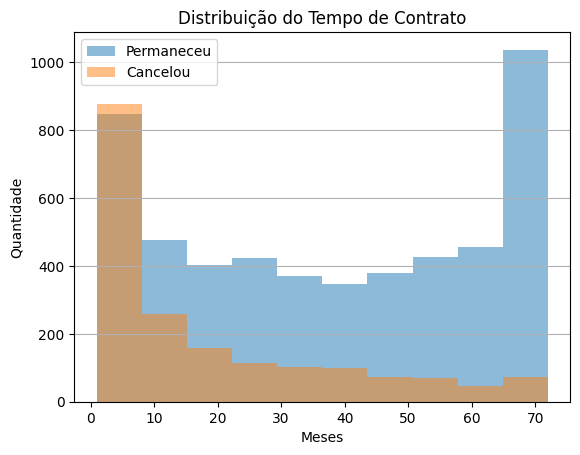

In [94]:
import matplotlib.pyplot as plt

plt.hist(df[df['Churn'] == 0]['customer_tenure'], alpha=0.5, label='Permaneceu')
plt.hist(df[df['Churn'] == 1]['customer_tenure'], alpha=0.5, label='Cancelou')

plt.title('Distribuição do Tempo de Contrato')
plt.xlabel('Meses')
plt.ylabel('Quantidade')
plt.legend()
plt.grid(axis='y')
plt.show()

Total Gasto

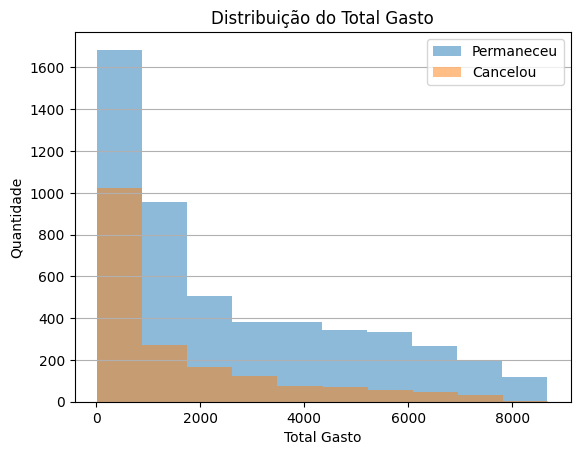

In [95]:
plt.hist(df[df['Churn'] == 0]['account_Charges_Total'], alpha=0.5, label='Permaneceu')
plt.hist(df[df['Churn'] == 1]['account_Charges_Total'], alpha=0.5, label='Cancelou')

plt.title('Distribuição do Total Gasto')
plt.xlabel('Total Gasto')
plt.ylabel('Quantidade')
plt.legend()
plt.grid(axis='y')
plt.show()

📊 RELATÓRIO FINAL — ANÁLISE DE CHURN

🔎 1. Introdução

O presente estudo tem como objetivo analisar o fenômeno de evasão de clientes (Churn) em uma empresa de telecomunicações. O churn representa o cancelamento do serviço por parte do cliente, impactando diretamente a receita e a sustentabilidade do negócio.

A análise busca identificar padrões comportamentais e características associadas aos clientes que cancelam o serviço, permitindo direcionar estratégias de retenção mais eficazes.

🧹 2. Limpeza e Tratamento de Dados

Foram realizadas as seguintes etapas:

Importação da base de dados

Padronização de nomes de colunas

Tratamento de valores nulos

Conversão de variáveis categóricas e numéricas

Criação de variáveis auxiliares (ex: Contas_Diarias)

Após o tratamento, os dados ficaram consistentes para análise exploratória.

📊 3. Análise Exploratória de Dados
🔹 Taxa Geral de Churn

A taxa de evasão identificada foi aproximadamente 26,5%, indicando que cerca de um quarto dos clientes cancelaram o serviço.

🔹 Variáveis Categóricas

A análise revelou que:

Clientes com contrato mensal apresentam maior taxa de churn.

Clientes que utilizam pagamento via electronic check apresentam maior propensão ao cancelamento.

Clientes com internet fibra ótica apresentam maior taxa de evasão.

Gênero não apresentou impacto relevante.

🔹 Variáveis Numéricas

Observou-se que:

Clientes que cancelam possuem tempo médio de contrato significativamente menor (17 meses vs 37 meses).

Clientes que cancelam possuem cobrança mensal mais elevada.

O total gasto é menor entre clientes que cancelam, refletindo menor tempo de permanência.

🎯 4. Conclusões e Insights

Os principais fatores associados ao churn são:

Tipo de contrato (mensal)

Tempo de permanência (tenure)

Valor da mensalidade

Método de pagamento

Clientes novos e com contratos mensais apresentam maior risco de evasão.

💡 5. Recomendações

Com base na análise, recomenda-se:

Incentivar migração de contratos mensais para anuais.

Criar programas de fidelização nos primeiros 6 meses.

Oferecer benefícios para clientes com mensalidades mais altas.

Monitorar clientes com perfil de risco elevado para ações preventivas.

🔎 Análise de Correlação (Extra)

Foi realizada análise de correlação entre as variáveis numéricas do dataset. Observou-se que o tempo de permanência (tenure) apresenta a correlação negativa mais significativa com churn, indicando que clientes mais novos possuem maior probabilidade de cancelamento.

A cobrança mensal apresentou correlação positiva moderada, sugerindo que valores mais altos estão associados a maior evasão.

Essa análise reforça a importância do tempo de relacionamento como principal fator preditivo.

📊 1️⃣ Matriz de Correlação

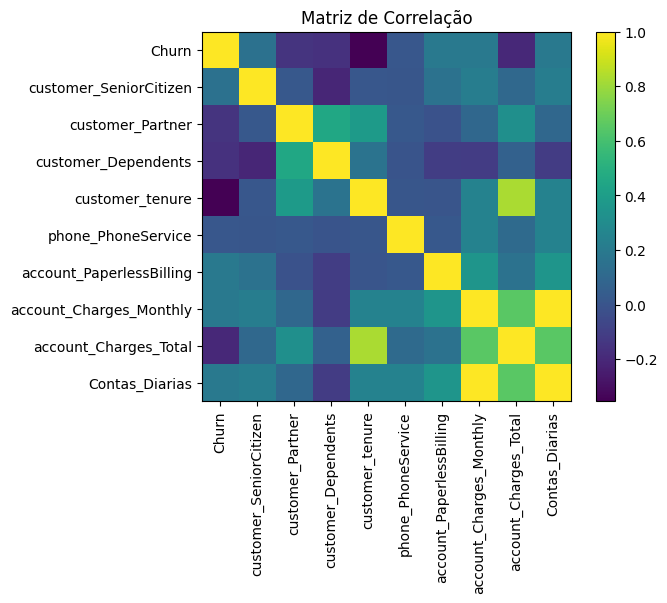

In [101]:
import matplotlib.pyplot as plt

correlacao = df.corr(numeric_only=True)

plt.figure()
plt.imshow(correlacao)
plt.title('Matriz de Correlação')
plt.colorbar()
plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=90)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)
plt.show()

🎯 2️⃣ Correlação direta com Churn

In [102]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
Contas_Diarias,0.192914
account_Charges_Monthly,0.192858
account_PaperlessBilling,0.191454
customer_SeniorCitizen,0.150541
phone_PhoneService,0.011691
customer_Partner,-0.149982
customer_Dependents,-0.163128
account_Charges_Total,-0.199484
customer_tenure,-0.354049


📌 Relação Conta Diária x Churn

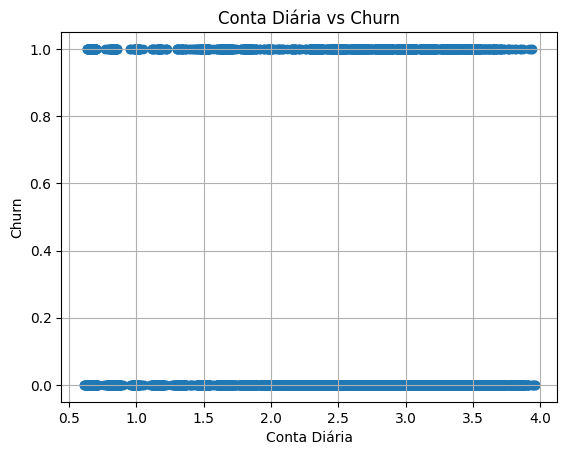

In [103]:
plt.scatter(df['Contas_Diarias'], df['Churn'])
plt.title('Conta Diária vs Churn')
plt.xlabel('Conta Diária')
plt.ylabel('Churn')
plt.grid()
plt.show()

In [104]:
df.to_csv("dados_tratados.csv",index= False)